<a href="https://colab.research.google.com/github/BrenoMafra13/COMP3132-Machine_Learning/blob/main/labs/Lab_Week09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LabWeek9: Prevent Overfitting - Part I

## Importing Dataset: IMDB

In [1]:
from keras.datasets import imdb
import numpy as np

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] += 1.  # set specific indices of results[i] to 1s
    return results

# Our vectorized training data
x_train = vectorize_sequences(train_data)
# Our vectorized test data
x_test = vectorize_sequences(test_data)
# Our vectorized labels
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Note:** We first encountered this dataset in `LabWeek5`. You can refer to that notebook for clarification on the text-to-numbers decoding process. Through vectorizing process we turn text data into vectors.

**Perform some sanity checks on the dataset:** For example, find the `shape` of the dataset and print samples to make sense of the data.

In [2]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)
print("First training review (vectorized, first 50 features):")
print(x_train[0][:50])
print("First training label:", y_train[0])

x_train shape: (25000, 10000)
y_train shape: (25000,)
x_test shape: (25000, 10000)
y_test shape: (25000,)
First training review (vectorized, first 50 features):
[ 0.  1.  6.  0. 15.  9.  3.  2.  3.  1.  0.  0.  6.  3.  3.  4. 11.  3.
  3.  2.  0.  1.  6.  0.  0.  4.  3.  0.  2.  0.  1.  0.  3.  2.  0.  1.
  4.  0.  4.  1.  0.  0.  0.  4.  0.  0.  1.  0.  1.  0.]
First training label: 1.0


## Fighting overfitting -  Reducing the network's size


The general workflow to find an appropriate model size is to start with relatively few layers and
parameters, and start increasing the size of the layers or adding new layers until you see diminishing returns with regard to the
validation loss.



**Note:** we use `test set` as our `validation set`.

**Complete the following code for `original model` architecture**

In [3]:
from keras import models
from keras import layers

original_model = models.Sequential()
original_model.add(layers.InputLayer(shape=(10000,)))
original_model.add(layers.Dense(16, activation='relu'))
original_model.add(layers.Dense(16, activation='relu'))
original_model.add(layers.Dense(1, activation='sigmoid'))

original_model.compile(optimizer='rmsprop',
                       loss='binary_crossentropy',
                       metrics=['acc'])

In [4]:
original_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

**Define another model with fewer parameters. 4 units in each hidden layer.**

In [5]:
smaller_model = models.Sequential()
smaller_model.add(layers.InputLayer(shape=(10000,)))
smaller_model.add(layers.Dense(4, activation='relu'))
smaller_model.add(layers.Dense(4, activation='relu'))
smaller_model.add(layers.Dense(1, activation='sigmoid'))
smaller_model.compile(optimizer='rmsprop',
                       loss='binary_crossentropy',
                       metrics=['acc'])


**Train (1) original_model and (2) smaller_model seperately for `epochs=20` and `batch_size=512`. Also pass `x_test` and `y_test` as `validation_data`.**

In [6]:
original_hist = original_model.fit(x_train, y_train,
                                   epochs=20,
                                   batch_size=512,
                                   validation_data=(x_test, y_test))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - acc: 0.6697 - loss: 0.6279 - val_acc: 0.8521 - val_loss: 0.4444
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - acc: 0.8722 - loss: 0.3930 - val_acc: 0.8762 - val_loss: 0.3498
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - acc: 0.9062 - loss: 0.2909 - val_acc: 0.8824 - val_loss: 0.3107
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - acc: 0.9205 - loss: 0.2364 - val_acc: 0.8736 - val_loss: 0.3255
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - acc: 0.9295 - loss: 0.2118 - val_acc: 0.8863 - val_loss: 0.2889
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - acc: 0.9344 - loss: 0.1858 - val_acc: 0.8800 - val_loss: 0.3147
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.9430 - loss: 0.1696 - val_acc: 0.8854 - val_loss: 0.2967
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - acc: 0.9465 - loss: 0.1561 - val_acc: 0.8845 - val_loss: 0.3017
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - acc: 0.952

In [7]:
smaller_hist = smaller_model.fit(x_train, y_train,
                                  epochs=20,
                                  batch_size=512,
                                  validation_data=(x_test, y_test))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - acc: 0.6100 - loss: 0.6625 - val_acc: 0.7744 - val_loss: 0.5919
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7863 - loss: 0.5661 - val_acc: 0.8277 - val_loss: 0.5314
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - acc: 0.8613 - loss: 0.5041 - val_acc: 0.8508 - val_loss: 0.4923
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - acc: 0.8904 - loss: 0.4564 - val_acc: 0.8742 - val_loss: 0.4669
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - acc: 0.9070 - loss: 0.4235 - val_acc: 0.8774 - val_loss: 0.4490
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - acc: 0.9207 - loss: 0.3999 - val_acc: 0.8750 - val_loss: 0.4389
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - acc: 0.9311 - loss: 0.3756 - val_acc: 0.8682 - val_loss: 0.4376
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - acc: 0.9378 - loss: 0.3586 - val_acc: 0.8752 - val_loss: 0.4268
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - acc: 0.9425

**`orginal_hist` and `smaller_hist` are `objects` returned after training the models.**
- We can get access to the `history` attribute of `origial_hist` object through dot operator.
- TODO: The history attribute is a data structure of type `dictionary` containing data about everything that happened during training. Show the `keys` of this `dictionary`.

In [8]:
print(original_hist.history.keys())

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])


**Plot `val_loss` vs. epochs for both models in one plot**

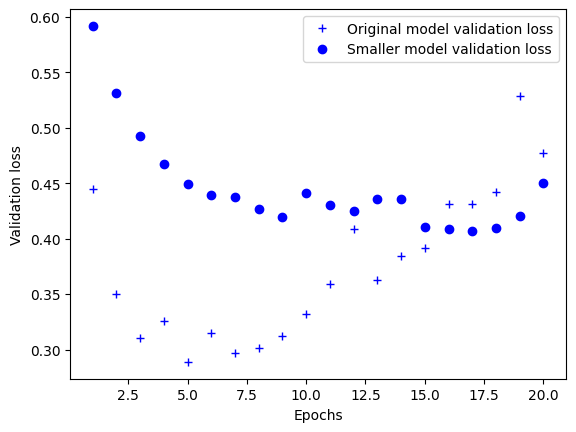

In [9]:
from matplotlib import pyplot as plt

original_val_loss = original_hist.history['val_loss']
smaller_val_loss = smaller_hist.history['val_loss']

epochs = range(1, len(original_val_loss) + 1)

plt.plot(epochs, original_val_loss, 'b+', label='Original model validation loss')
plt.plot(epochs, smaller_val_loss, 'bo', label='Smaller model validation loss')
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.legend()

plt.show()

**Plot training `loss` vs. epochs for both models in one plot**

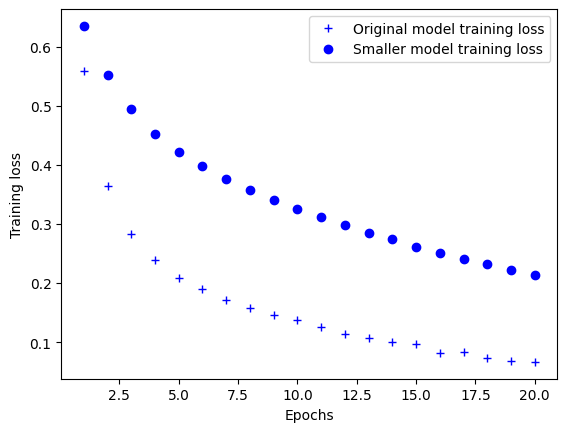

In [10]:
original_train_loss = original_hist.history['loss']
smaller_train_loss = smaller_hist.history['loss']

epochs = range(1, len(original_train_loss) + 1)

plt.plot(epochs, original_train_loss, 'b+', label='Original model training loss')
plt.plot(epochs, smaller_train_loss, 'bo', label='Smaller model training loss')
plt.xlabel('Epochs')
plt.ylabel('Training loss')
plt.legend()

plt.show()

**Questions:** Which model overfits earlier? How can you see the size of the model on overfitting?

The larger model overfits early because it memorizes the training data instead of learning general patterns. While its training loss keeps dropping, the validation loss spikes quickly, showing it has lost the ability to generalize to new data.

**Now define a very large model (e.g., with 512 units in hidden layer) and compare the `loss` and `val_loss` of this big model and the `original model` and `smaller_model`.**

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 26s 518ms/step - acc: 0.6490 - loss: 0.7661 - val_acc: 0.8685 - val_loss: 0.3454
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 27s 552ms/step - acc: 0.8673 - loss: 0.3559 - val_acc: 0.8810 - val_loss: 0.2999
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 23s 480ms/step - acc: 0.8981 - loss: 0.2614 - val_acc: 0.8882 - val_loss: 0.2819
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 374ms/step - acc: 0.9178 - loss: 0.2084 - val_acc: 0.8895 - val_loss: 0.2812
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 25s 474ms/step - acc: 0.9299 - loss: 0.1787 - val_acc: 0.8418 - val_loss: 0.4697
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 23s 482ms/step - acc: 0.9438 - loss: 0.1505 - val_acc: 0.8642 - val_loss: 0.3885
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 24s 490ms/step - acc: 0.9616 - loss: 0.1030 - val_acc: 0.8439 - val_loss: 0.4383
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 377ms/step - acc: 0.9705 - loss: 0.0819 - val_acc: 0.8815 - val_loss: 0.4084
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 432ms/

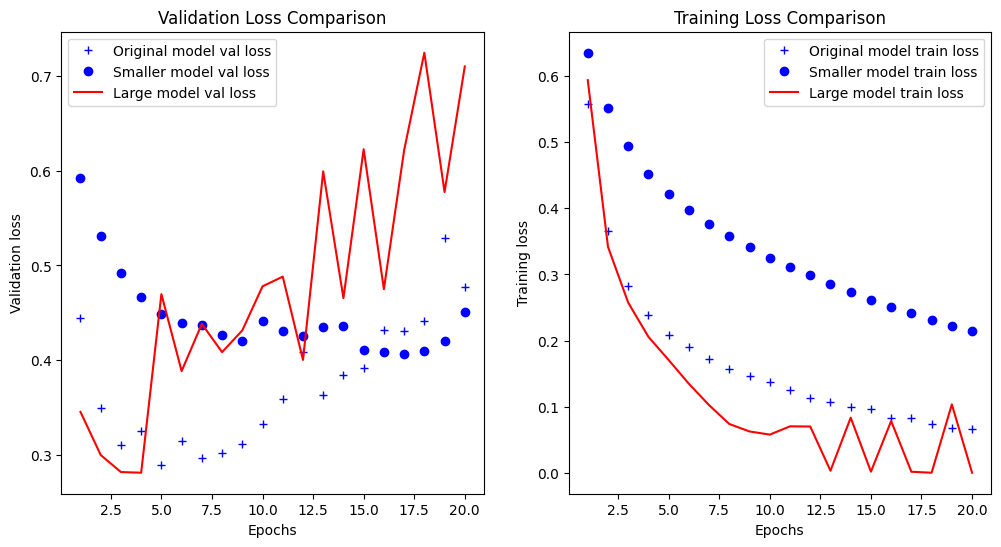

In [11]:
large_model = models.Sequential()
large_model.add(layers.InputLayer(shape=(10000,)))
large_model.add(layers.Dense(512, activation='relu'))
large_model.add(layers.Dense(512, activation='relu'))
large_model.add(layers.Dense(1, activation='sigmoid'))
large_model.compile(optimizer='rmsprop',
                    loss='binary_crossentropy',
                    metrics=['acc'])

large_hist = large_model.fit(x_train, y_train,
                             epochs=20,
                             batch_size=512,
                             validation_data=(x_test, y_test))

large_val_loss = large_hist.history['val_loss']
large_train_loss = large_hist.history['loss']

original_val_loss = original_hist.history['val_loss']
smaller_val_loss = smaller_hist.history['val_loss']

epochs = range(1, len(original_val_loss) + 1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, original_val_loss, 'b+', label='Original model val loss')
plt.plot(epochs, smaller_val_loss, 'bo', label='Smaller model val loss')
plt.plot(epochs, large_val_loss, 'r-', label='Large model val loss')
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.legend()
plt.title('Validation Loss Comparison')

plt.subplot(1, 2, 2)
plt.plot(epochs, original_train_loss, 'b+', label='Original model train loss')
plt.plot(epochs, smaller_train_loss, 'bo', label='Smaller model train loss')
plt.plot(epochs, large_train_loss, 'r-', label='Large model train loss')
plt.xlabel('Epochs')
plt.ylabel('Training loss')
plt.legend()
plt.title('Training Loss Comparison')

plt.show()

**Discuss the results**

The massive model hits almost zero training loss almost instantly by memorizing the data, but its validation loss spikes early and aggressively. It is a classic case of too much capacity killing generalization—proving that bigger isn't always better if the model cannot handle unseen data.

## Fighting overfitting - Adding weight regularization


A common way to mitigate overfitting is to put constraints on the complexity
of a network by forcing its weights to only take small values. This is called
"weight regularization", and it is done by adding to the loss function of the network a _cost_ associated with having large weights. This
cost comes in two flavors:

* L1 regularization, where the cost added is proportional to the _absolute value of the weights coefficients_ (i.e. to what is called the
"L1 norm" of the weights).
* L2 regularization, where the cost added is proportional to the _square of the value of the weights coefficients_ (i.e. to what is called
the "L2 norm" of the weights). L2 regularization is also called _weight decay_ in the context of neural networks. Don't let the different
name confuse you: weight decay is mathematically the exact same as L2 regularization.

In Keras, weight regularization is added by passing _weight regularizer instances_ to layers as keyword arguments.


**Complere the model below**

In [12]:
from keras import regularizers

l2_model = models.Sequential()
l2_model.add(layers.InputLayer(shape=(10000,)))
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001),
                          activation='relu'))
l2_model.add(layers.Dense(16, kernel_regularizer=regularizers.l2(0.001),
                          activation='relu'))
l2_model.add(layers.Dense(1, activation='sigmoid'))

In [13]:
l2_model.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['acc'])

`l2(0.001)` means that every coefficient in the weight matrix of the layer will add `0.001 * weight_coefficient_value` to the total loss of
the network. Note that because this penalty is _only added at training time_, the loss for this network will be much higher at training
than at test time.



**Train the model with regularization and compare the validation loss between this model and the `original_model` and `smaller model`.**

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 105ms/step - acc: 0.6973 - loss: 0.6288 - val_acc: 0.8465 - val_loss: 0.4421
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - acc: 0.8907 - loss: 0.3593 - val_acc: 0.8776 - val_loss: 0.3684
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - acc: 0.9126 - loss: 0.2954 - val_acc: 0.8849 - val_loss: 0.3379
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - acc: 0.9202 - loss: 0.2714 - val_acc: 0.8849 - val_loss: 0.3372
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - acc: 0.9301 - loss: 0.2469 - val_acc: 0.8844 - val_loss: 0.3389
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - acc: 0.9370 - loss: 0.2326 - val_acc: 0.8629 - val_loss: 0.4019
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - acc: 0.9365 - loss: 0.2298 - val_acc: 0.8850 - val_loss: 0.3461
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - acc: 0.9445 - loss: 0.2160 - val_acc: 0.8736 - val_loss: 0.3880
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.942

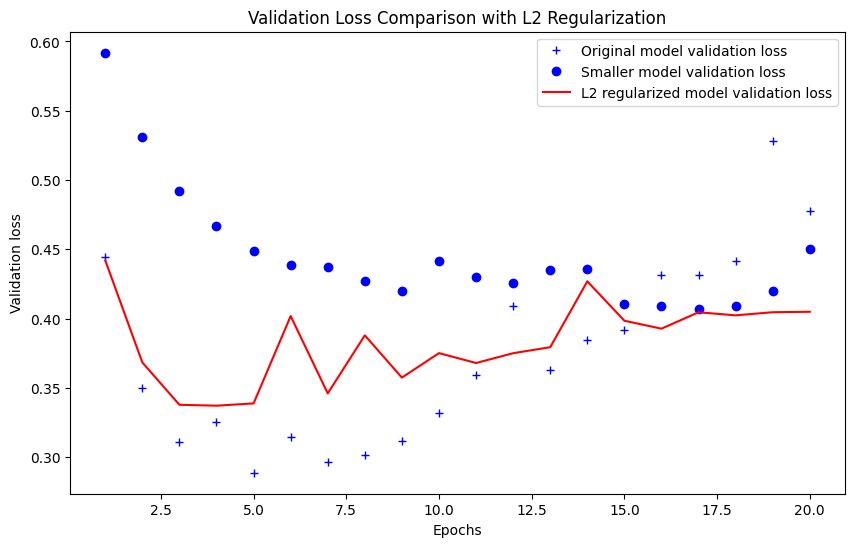

In [14]:
l2_model.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['acc'])

l2_hist = l2_model.fit(x_train, y_train,
                      epochs=20,
                      batch_size=512,
                      validation_data=(x_test, y_test))

l2_val_loss = l2_hist.history['val_loss']

original_val_loss = original_hist.history['val_loss']
smaller_val_loss = smaller_hist.history['val_loss']

epochs = range(1, len(original_val_loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, original_val_loss, 'b+', label='Original model validation loss')
plt.plot(epochs, smaller_val_loss, 'bo', label='Smaller model validation loss')
plt.plot(epochs, l2_val_loss, 'r-', label='L2 regularized model validation loss')
plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.legend()
plt.title('Validation Loss Comparison with L2 Regularization')

plt.show()

**Note:** As alternatives to L2 regularization, you could use one of the following Keras weight regularizers:

In [15]:
from keras import regularizers

# L1 regularization
regularizers.l1(0.001)

# L1 and L2 regularization at the same time
regularizers.l1_l2(l1=0.001, l2=0.001)

## Recap

To recap: here the most common ways to prevent overfitting in neural networks:

* Getting more training data.
* Reducing the capacity of the network.
* Adding weight regularization.
* Adding dropout. (next session)

**Observation 1:** The bigger network gets its training loss near zero very quickly. The more capacity the network has, the quicker it will be
able to model the training data (resulting in a low training loss), but the more susceptible it is to overfitting (resulting in a large
difference between the training and validation loss).

**Observation 2:** The model with L2 regularization has become much more resistant to overfitting than the reference model,
even though both models have the same number of parameters.